In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import kagglehub
import os

print("All libraries imported!")

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [13]:
# List files inside dataset folder
os.listdir(path)

['Titanic-Dataset.csv']

In [14]:
# Load CSV file

df = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"))

# Display first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# 1. Check dimensions
print(f"Dataset Shape: {df.shape}")
print(f"Dataset size: {df.size}")

Dataset Shape: (891, 12)
Dataset size: 10692


In [16]:
# 2. Initial Statistics
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [17]:
# 3. Check for missing values
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())


--- Missing Values Per Column ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [18]:
# Checking data types and column info
print("--- Column Descriptions and Types ---")
df.info()

--- Column Descriptions and Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
# Check current types
print("Types before conversion:\n", df.dtypes)

Types before conversion:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [20]:
#Convert object columns into category data type
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("Updated Data Types After Conversion:")
print("--------------------------------------")
print(df[['Sex','Embarked']].dtypes)
print()

# Display first few rows to verify changes
print("Preview of Updated Dataset:")
print("--------------------------------------")
print(df[['Sex','Embarked']].head())
print()

# Display category levels for each column
print("Categories in 'Sex' column:", df['Sex'].cat.categories)
print("Categories in 'Embarked' column:", df['Embarked'].cat.categories)

Updated Data Types After Conversion:
--------------------------------------
Sex         category
Embarked    category
dtype: object

Preview of Updated Dataset:
--------------------------------------
      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S

Categories in 'Sex' column: Index(['female', 'male'], dtype='object')
Categories in 'Embarked' column: Index(['C', 'Q', 'S'], dtype='object')


In [21]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
# Replace missing Age values with mean age
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
# Replace missing Embarked values with most frequent value
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode())
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:
# Check number of missing values in Cabin column
print("Missing Cabin values:", df['Cabin'].isnull().sum())

Missing Cabin values: 687


In [26]:
# Replace missing cabin values with 'Unknown'
df['Cabin'] = df['Cabin'].fillna("Unknown")

# Display updated values
print("Updated Cabin column:")
print(df['Cabin'].head())

Updated Cabin column:
0    Unknown
1        C85
2    Unknown
3       C123
4    Unknown
Name: Cabin, dtype: object


In [27]:
# Again Check number of missing values in Cabin column
print("Missing Cabin values:", df['Cabin'].isnull().sum())

Missing Cabin values: 0


In [28]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [29]:
# Step: Convert Categorical Variables into Numerical Variables
# Machine learning algorithms cannot work directly with text
# (categorical values such as 'male', 'female', 'S', 'C', etc.)
# Therefore, we convert them into numeric form using Label Encoding.

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

print("Original 'Sex' column values:")
print(df['Sex'].head())
print()

print("Original 'Embarked' column values:")
print(df['Embarked'].head())
print()

# Apply Label Encoding
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])


print("After Label Encoding:")
print("-----------------------------------")

print("Encoded 'Sex' column values:")
print(df['Sex'].head())
print()

print("Encoded 'Embarked' column values:")
print(df['Embarked'].head())
print()

# Show mapping information
print("Encoding Information:")
print("-----------------------------------")
print("Sex column: female = 0 , male = 1")
print("Embarked column: categories converted to numeric values")

Original 'Sex' column values:
0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: category
Categories (2, object): ['female', 'male']

Original 'Embarked' column values:
0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: category
Categories (3, object): ['C', 'Q', 'S']

After Label Encoding:
-----------------------------------
Encoded 'Sex' column values:
0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64

Encoded 'Embarked' column values:
0    2
1    0
2    2
3    2
4    2
Name: Embarked, dtype: int64

Encoding Information:
-----------------------------------
Sex column: female = 0 , male = 1
Embarked column: categories converted to numeric values


In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2


In [31]:
# Convert passenger class into separate binary columns
#One-Hot Encoding
df = pd.get_dummies(df, columns=['Pclass'])
df.head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_1,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2,False,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,True,False,False
2,3,1,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2,False,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,True,False,False
4,5,0,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2,False,False,True


In [32]:
# Min-Max Normalization: (x - min) / (max - min)
df['Fare_normalized'] = (df['Fare'] - df['Fare'].min()) / (df['Fare'].max() - df['Fare'].min())

print("First 5 rows of normalized fare:")
print(df[['Fare', 'Fare_normalized']].head())

First 5 rows of normalized fare:
      Fare  Fare_normalized
0   7.2500         0.014151
1  71.2833         0.139136
2   7.9250         0.015469
3  53.1000         0.103644
4   8.0500         0.015713


In [33]:
# Display final dataset
df.head(20)

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_1,Pclass_2,Pclass_3,Fare_normalized
0,1,0,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,Unknown,2,False,False,True,0.014151
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C85,0,True,False,False,0.139136
2,3,1,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,Unknown,2,False,False,True,0.015469
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,C123,2,True,False,False,0.103644
4,5,0,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,Unknown,2,False,False,True,0.015713
5,6,0,"Moran, Mr. James",1,29.699118,0,0,330877,8.4583,Unknown,1,False,False,True,0.016510
6,7,0,"McCarthy, Mr. Timothy J",1,54.000000,0,0,17463,51.8625,E46,2,True,False,False,0.101229
7,8,0,"Palsson, Master. Gosta Leonard",1,2.000000,3,1,349909,21.0750,Unknown,2,False,False,True,0.041136
8,9,1,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.000000,0,2,347742,11.1333,Unknown,2,False,False,True,0.021731
9,10,1,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.000000,1,0,237736,30.0708,Unknown,0,False,True,False,0.058694


In [34]:
#here :Meaning:
# S → Southampton
# C → Cherbourg
# Q → Queenstown 

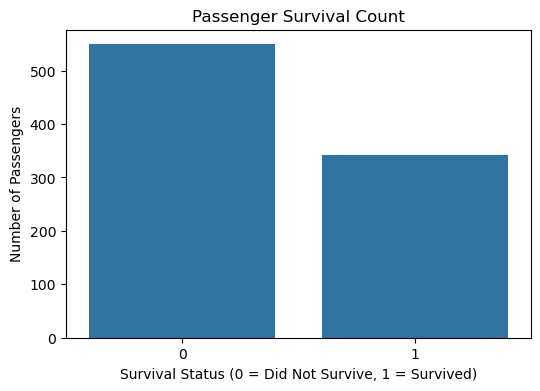

In [35]:
# Visualization: Passenger Survival Count

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Passenger Survival Count")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.show()